#**Economía Informal y Subempleo**

Integrantes:


*  Jara Mesia, Mateo Francisco
*  Moron Espino, Jesus Maximiliano
*  Perez Nuñez, Aeiderik Calet
*  Quijano Rodriguez, César Ignacio
*  Quispe Tocasca, David Alexander








### 1. Cargar el dataset en un DataFrame utilizando pandas.

In [ ]:
# Importamos las librerías necesarias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2. Mostrar las primeras y últimas 5 filas del conjunto de datos.

In [ ]:
# Descargamos y cargamos el archivo de datos del mercado laboral
df = pd.read_csv('/content/sample_data/Equipo6_EconomiaInformal.csv')
#Mostramos las primeras 5 filas
df.head(5)

,ID_Trabajador,Edad,Sexo,Departamento,Zona,Tipo_Actividad,Horas_Trabajadas_Semana,Ingreso_Mensual,Acceso_Beneficios,Tiene_Contrato_Escrito,Formalidad
0,1,58,Masculino,Lima,Urbana,Servicio doméstico,25,920.73,Solo salud,No,Informal
1,2,20,Masculino,Arequipa,Urbana,Comercio ambulante,33,1628.77,Salud y pensión,No,Formal
2,3,50,Masculino,Huancavelica,Urbana,Empleo formal,38,1108.75,Ninguno,Sí,Informal
3,4,19,Masculino,Huancavelica,Urbana,Empleo formal,22,1099.76,Ninguno,No,Formal
4,5,63,Femenino,Cusco,Urbana,Empleo formal,12,757.28,Salud y pensión,No,Informal


In [ ]:
# Mostramos las últimas 5 filas
df.tail(5)

,ID_Trabajador,Edad,Sexo,Departamento,Zona,Tipo_Actividad,Horas_Trabajadas_Semana,Ingreso_Mensual,Acceso_Beneficios,Tiene_Contrato_Escrito,Formalidad
1295,1296,51,Masculino,Arequipa,Urbana,Microempresa,58,569.96,Ninguno,Sí,Informal
1296,1297,30,Masculino,San Martín,Urbana,Empleo formal,19,408.22,Solo salud,Sí,Informal
1297,1298,25,Masculino,Cusco,Rural,Empleo formal,53,837.61,Ninguno,No,Informal
1298,1299,57,Femenino,Lima,Urbana,Comercio ambulante,47,1540.77,Solo salud,Sí,Informal
1299,1300,44,Femenino,Arequipa,Rural,Comercio ambulante,57,1012.31,Solo salud,Sí,Informal


### 3. Identificar los tipos de datos y valores faltantes. Comentar qué limpieza sería necesaria.

In [ ]:
# Tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Trabajador            1300 non-null   int64  
 1   Edad                     1300 non-null   int64  
 2   Sexo                     1300 non-null   object 
 3   Departamento             1300 non-null   object 
 4   Zona                     1300 non-null   object 
 5   Tipo_Actividad           1300 non-null   object 
 6   Horas_Trabajadas_Semana  1300 non-null   int64  
 7   Ingreso_Mensual          1300 non-null   float64
 8   Acceso_Beneficios        1300 non-null   object 
 9   Tiene_Contrato_Escrito   1300 non-null   object 
 10  Formalidad               1300 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 111.8+ KB


In [ ]:
# Valores faltantes
valores_faltantes = df.isnull().sum()
valores_faltantes

,0
ID_Trabajador,0
Edad,0
Sexo,0
Departamento,0
Zona,0
Tipo_Actividad,0
Horas_Trabajadas_Semana,0
Ingreso_Mensual,0
Acceso_Beneficios,0
Tiene_Contrato_Escrito,0


No sería necesario hacer una limpieza porque no hay valores faltantes.

### 4. Crear una nueva columna que identifique como subempleado a quien trabaja menos de 30 horas y no tiene contrato escrito.


In [ ]:
# Creamos la columna Subempleado
# Criterio: menos de 30 horas semanales Y sin contrato escrito
df['Subempleado'] = (df['Horas_Trabajadas_Semana'] < 30) & (df['Tiene_Contrato_Escrito'] == 'No')

# Verificamos el resultado
print(df['Subempleado'].value_counts())
print()
print(df[['Horas_Trabajadas_Semana', 'Tiene_Contrato_Escrito', 'Subempleado']].head(10))

Subempleado
False    969
True     331
Name: count, dtype: int64

   Horas_Trabajadas_Semana Tiene_Contrato_Escrito  Subempleado
0                       25                     No         True
1                       33                     No        False
2                       38                     Sí        False
3                       22                     No         True
4                       12                     No         True
5                       30                     Sí        False
6                       23                     Sí        False
7                       14                     Sí        False
8                       46                     Sí        False
9                       29                     No         True


### 5. Realizar gráficos que muestren:

*   Ingreso promedio por tipo de actividad.



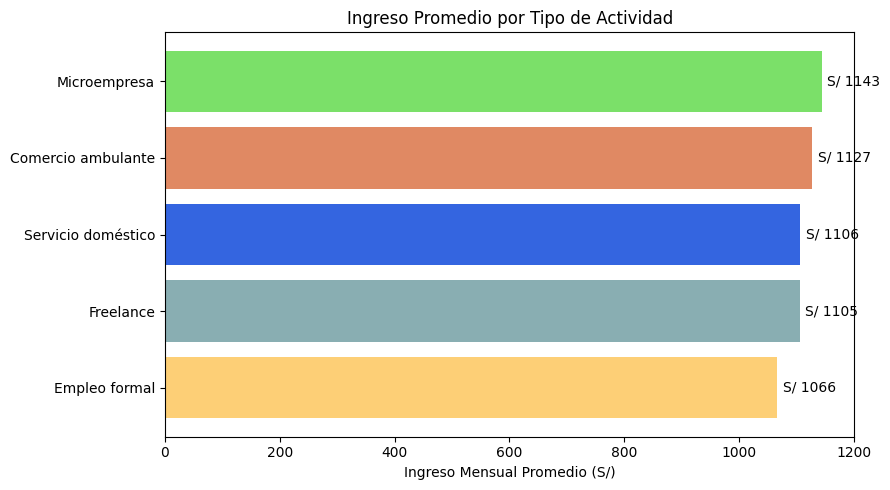

In [ ]:
ingreso_actividad = df.groupby('Tipo_Actividad')['Ingreso_Mensual'].mean().sort_values()

plt.figure(figsize=(9, 5))
bars = plt.barh(ingreso_actividad.index, ingreso_actividad.values, color=['#FDCF76','#89AEB2','#3465e0','#E08963','#7be069'])
plt.xlabel('Ingreso Mensual Promedio (S/)')
plt.title('Ingreso Promedio por Tipo de Actividad')
for bar, val in zip(bars, ingreso_actividad.values):
    plt.text(val + 10, bar.get_y() + bar.get_height()/2, f'S/ {val:.0f}', va='center')
plt.tight_layout()
plt.show()



*   Proporción de trabajadores con y sin contrato escrito por zona.




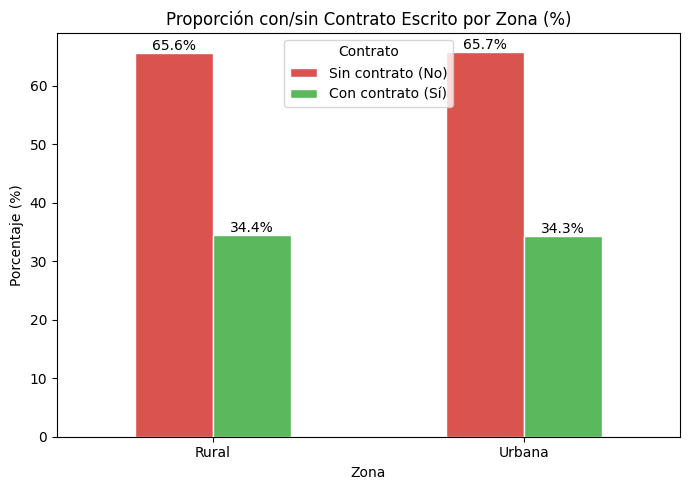

In [ ]:
contrato_zona = df.groupby(['Zona', 'Tiene_Contrato_Escrito']).size().unstack()
contrato_zona_pct = contrato_zona.div(contrato_zona.sum(axis=1), axis=0) * 100

ax = contrato_zona_pct.plot(kind='bar', figsize=(7, 5), color=['#d9534f','#5cb85c'], edgecolor='white')
plt.title('Proporción con/sin Contrato Escrito por Zona (%)')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Zona')
plt.xticks(rotation=0)
plt.legend(['Sin contrato (No)', 'Con contrato (Sí)'], title='Contrato')
for p in ax.patches:
    ax.annotate(str(round(p.get_height(), 1)) + '%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()



*   Distribución de acceso a beneficios según formalidad.




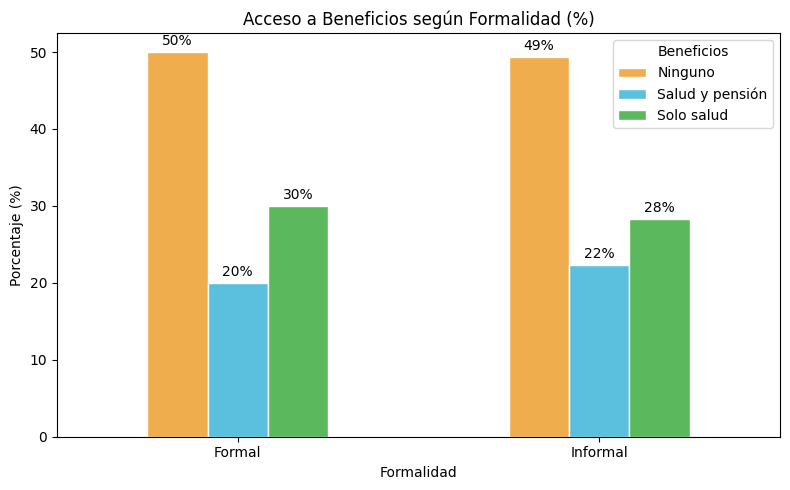

In [ ]:
#  Distribución de acceso a beneficios según formalidad
beneficios_formal = df.groupby(['Formalidad', 'Acceso_Beneficios']).size().unstack()
beneficios_pct = beneficios_formal.div(beneficios_formal.sum(axis=1), axis=0) * 100
ax = beneficios_pct.plot(kind='bar', figsize=(8, 5), color=['#f0ad4e','#5bc0de','#5cb85c'], edgecolor='white')
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', padding=3)
plt.title('Acceso a Beneficios según Formalidad (%)')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Formalidad')
plt.xticks(rotation=0)
plt.legend(title='Beneficios')
plt.tight_layout()
plt.show()

### 6. Clasificar a los trabajadores como 'Alta precariedad', 'Moderada precariedad' o 'Empleo estable', considerando horas trabajadas, beneficios y formalidad.

In [ ]:
# Inicializamos la columna con 'Moderada_precariedad' como valor base
df['Precariedad'] = 'Moderada_precariedad'

# Filtro para Precariedad Alta (Considerando Horas, Beneficios y Formalidad):
# Ejemplo: Sin contrato, sin beneficios Y (más de 48 horas o menos de 20 horas)
df.loc[(df['Acceso_Beneficios'] == 'Ninguno') &
       (df['Tiene_Contrato_Escrito'] == 'No') &
       ((df['Horas_Trabajadas_Semana'] > 48) | (df['Horas_Trabajadas_Semana'] < 20)),
       'Precariedad'] = 'Alta_precariedad'

# Filtro para Precariedad Estable
df.loc[(df['Acceso_Beneficios'] == 'Salud y pensión') &
       (df['Tiene_Contrato_Escrito'] == 'Sí'),
       'Precariedad'] = 'Empleo_estable'

conteo_precariedad = df['Precariedad'].value_counts()
display(conteo_precariedad)

,count
Precariedad,
Moderada_precariedad,1029
Alta_precariedad,170
Empleo_estable,101


### 7. Mostrar un ranking de departamentos con mayor proporción de trabajadores en alta precariedad laboral.

In [ ]:
# Creamos una tabla cruzada con proporciones por departamento
tabla_proporciones = pd.crosstab(df['Departamento'], df['Precariedad'], normalize='index')

# Extraemos solo la columna de 'Alta_precariedad' y la ordenamos de mayor a menor
ranking_precariedad = tabla_proporciones['Alta_precariedad'].sort_values(ascending=False)

# Convertimos a porcentaje para mejor lectura y mostramos
display(ranking_precariedad * 100)

,Alta_precariedad
Departamento,
Lima,17.156863
San Martín,15.178571
Huancavelica,13.709677
Arequipa,11.111111
Lambayeque,10.606061
Cusco,10.476190


### 8. Realizar, creativamente un análisis adicional que muestre importantes hallazgos económicos, aplicando Ciencia de datos.
Evaluamos si los niveles de precariedad definidos anteriormente se reflejan en una diferencia significativa de ingresos mensuales promedio.

In [ ]:
# Agrupamos por Precariedad y calculamos el promedio del Ingreso_Mensual
ingreso_por_precariedad = df.groupby('Precariedad')['Ingreso_Mensual'].mean().sort_values()

# Redondeamos los resultados a 4 decimales
ingreso_por_precariedad = ingreso_por_precariedad.round(2)

# Mostramos los resultados
print("Ingreso Mensual Promedio por Nivel de Precariedad:")
display(ingreso_por_precariedad)

Ingreso Mensual Promedio por Nivel de Precariedad:


,Ingreso_Mensual
Precariedad,
Empleo_estable,1059.73
Alta_precariedad,1115.69
Moderada_precariedad,1118.26


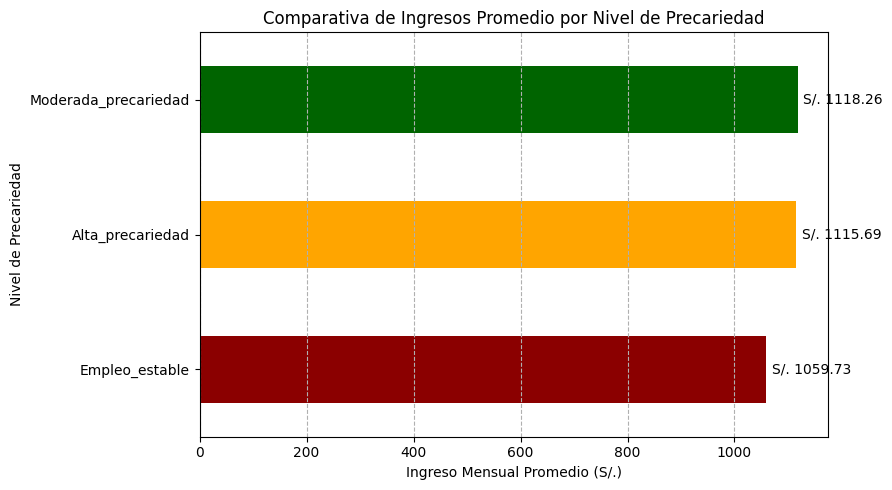

In [ ]:
# Grafico económico
ingreso_por_precariedad = df.groupby('Precariedad')['Ingreso_Mensual'].mean().sort_values()
ingreso_por_precariedad = ingreso_por_precariedad.round(2)
plt.figure(figsize=(9, 5))
ax = ingreso_por_precariedad.plot(kind='barh', color=['darkred', 'orange', 'darkgreen'])
plt.title('Comparativa de Ingresos Promedio por Nivel de Precariedad')
plt.xlabel('Ingreso Mensual Promedio (S/.)')
plt.ylabel('Nivel de Precariedad')
plt.grid(axis='x', linestyle='--', alpha=1)
for index, value in enumerate(ingreso_por_precariedad):
    ax.text(value + 10, index, f'S/. {value:.2f}', va='center', ha='left')

plt.tight_layout()
plt.show()